# 1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). В первой колонке файла с данными записано, была или нет реакция. Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку на обучающую и тестовую, используя функцию train_test_split с параметрами test_size = 0.8 и random_state = 241.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import log_loss

df = pd.read_csv(r"/content/gbm-data.csv")
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=241)

# 2. Обучите GradientBoostingClassifier с параметрами n_estimators=250,verbose=True, random_state=241 и для каждого значения learning_rate из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее: • Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой итерации. • Преобразуйте полученное предсказание по формуле 1 1+e −y_pred , где y_pred — предсказанное значение. • Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.

      Iter       Train Loss   Remaining Time 
         1           1.0190           57.38s
         2           0.9192           49.12s
         3           0.8272           42.74s
         4           0.7834           41.11s
         5           0.7109           38.29s
         6           0.6368           36.95s
         7           0.5797           37.25s
         8           0.5610           37.70s
         9           0.5185           37.00s
        10           0.4984           37.10s
        20           0.1999           37.56s
        30           0.1313           47.42s
        40           0.0790           44.08s
        50           0.0511           40.14s
        60           0.0352           36.10s
        70           0.0245           32.18s
        80           0.0162           28.02s
        90           0.0114           24.62s
       100           0.0077           21.73s
       200           0.0002            5.85s
LR: 1 | Min Loss: 0.58 at iteration: 0


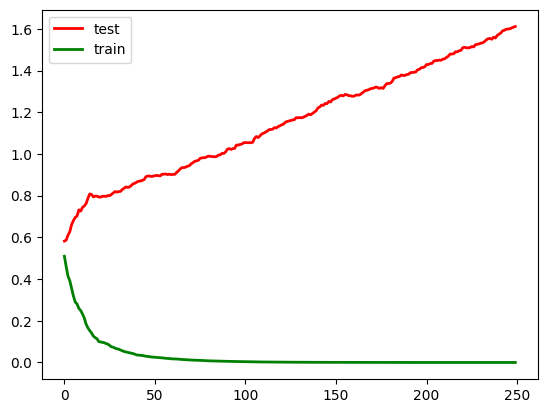

      Iter       Train Loss   Remaining Time 
         1           1.1255           47.19s
         2           1.0035           42.25s
         3           0.9386           40.07s
         4           0.8844           41.21s
         5           0.8381           50.30s
         6           0.7995           56.08s
         7           0.7559           56.30s
         8           0.7205           54.34s
         9           0.6958           51.10s
        10           0.6725           48.40s
        20           0.4672           42.77s
        30           0.3179           38.32s
        40           0.2274           33.29s
        50           0.1774           30.55s
        60           0.1394           27.80s
        70           0.1050           25.11s
        80           0.0805           22.93s
        90           0.0650           21.15s
       100           0.0511           19.40s
       200           0.0058            5.02s
LR: 0.5 | Min Loss: 0.56 at iteration: 4


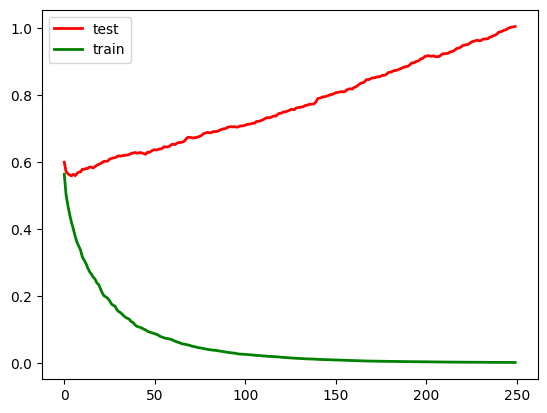

      Iter       Train Loss   Remaining Time 
         1           1.2095           17.91s
         2           1.1006           18.09s
         3           1.0240           20.46s
         4           0.9729           22.20s
         5           0.9387           23.03s
         6           0.8948           23.36s
         7           0.8621           24.16s
         8           0.8360           24.58s
         9           0.8171           24.81s
        10           0.7883           24.60s
        20           0.6164           23.53s
        30           0.4933           22.58s
        40           0.4248           19.99s
        50           0.3345           17.88s
        60           0.2760           16.30s
        70           0.2263           14.97s
        80           0.1971           13.86s
        90           0.1693           12.76s
       100           0.1388           11.74s
       200           0.0294            3.78s
LR: 0.3 | Min Loss: 0.54 at iteration: 18


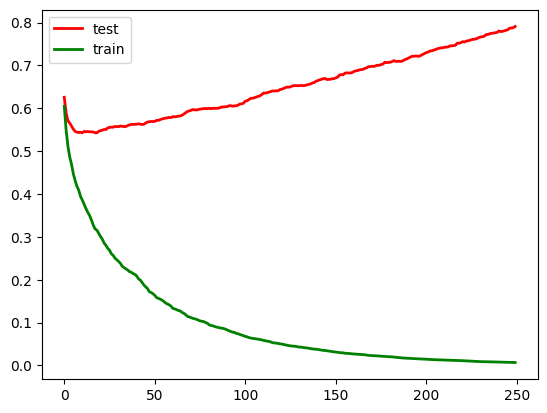

      Iter       Train Loss   Remaining Time 
         1           1.2613           17.73s
         2           1.1715           16.91s
         3           1.1009           16.30s
         4           1.0529           16.37s
         5           1.0130           16.59s
         6           0.9740           16.50s
         7           0.9475           16.37s
         8           0.9197           16.26s
         9           0.8979           16.37s
        10           0.8730           16.18s
        20           0.7207           15.63s
        30           0.6055           14.88s
        40           0.5244           14.18s
        50           0.4501           13.43s
        60           0.3908           12.72s
        70           0.3372           12.00s
        80           0.3009           11.32s
        90           0.2603           10.63s
       100           0.2327           10.17s
       200           0.0835            4.59s
LR: 0.2 | Min Loss: 0.53 at iteration: 36


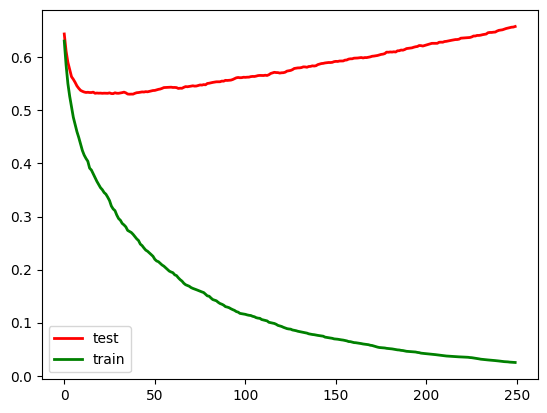

      Iter       Train Loss   Remaining Time 
         1           1.3199           17.12s
         2           1.2645           16.72s
         3           1.2170           16.32s
         4           1.1775           16.33s
         5           1.1404           16.44s
         6           1.1106           16.58s
         7           1.0844           16.79s
         8           1.0617           16.68s
         9           1.0411           16.52s
        10           1.0223           16.51s
        20           0.8864           15.30s
        30           0.7844           14.82s
        40           0.7176           14.23s
        50           0.6590           13.64s
        60           0.6120           13.00s
        70           0.5599           12.30s
        80           0.5242           11.60s
        90           0.4829           10.90s
       100           0.4473           10.21s
       200           0.2379            3.62s
LR: 0.1 | Min Loss: 0.53 at iteration: 51


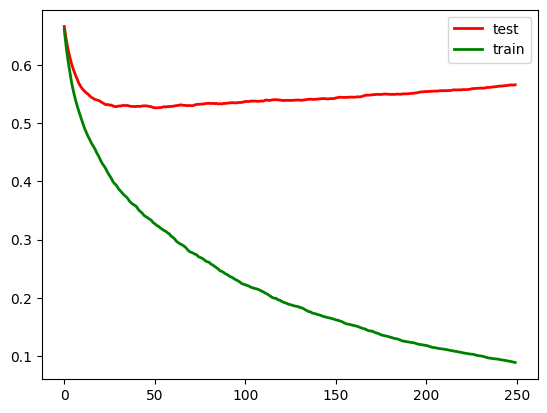

In [2]:
learning_rates = [1, 0.5, 0.3, 0.2, 0.1]

for lr in learning_rates:
    clf = GradientBoostingClassifier(n_estimators=250, verbose=True, random_state=241, learning_rate=lr)
    clf.fit(X_train, y_train)

    train_loss = []
    test_loss = []

    for y_pred_train in clf.staged_decision_function(X_train):
        train_loss.append(log_loss(y_train, 1 / (1 + np.exp(-y_pred_train))))

    for y_pred_test in clf.staged_decision_function(X_test):
        test_loss.append(log_loss(y_test, 1 / (1 + np.exp(-y_pred_test))))

    print(f"LR: {lr} | Min Loss: {round(min(test_loss), 2)} at iteration: {test_loss.index(min(test_loss))}")

    plt.figure()
    plt.plot(test_loss, 'r', linewidth=2, label='test')
    plt.plot(train_loss, 'g', linewidth=2, label='train')
    plt.legend()
    plt.show()

# 3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или недообучение (underfitting)? В ответе укажите одно из слов overfitting либо underfitting.

In [5]:
print("overfitting")

overfitting


# 4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate = 0.2.

In [10]:
print("0.53 36")

0.53 36


# 5. На этих же данных обучите RandomForestClassifier с количеством деревьев, равным количеству итераций, на котором достигается наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию. Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью функции predict_proba. В данном случае брать сигмоиду от оценки вероятности класса не нужно)

In [12]:
n_best_trees = 36

rf = RandomForestClassifier(n_estimators=n_best_trees, random_state=241)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)
rf_log_loss = log_loss(y_test, rf_probs)

print(round(rf_log_loss, 2))

0.54
